In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv('updated_data.csv')
df.head()

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1,1,14.75
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0,0,0.00
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0,1,19.06
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0,0,0.00
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1,1,13.42


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   branch                     1000 non-null   object 
 1   college_tier               1000 non-null   object 
 2   cgpa                       1000 non-null   float64
 3   backlogs                   1000 non-null   int64  
 4   coding_skills              1000 non-null   float64
 5   dsa_score                  1000 non-null   float64
 6   aptitude_score             1000 non-null   float64
 7   communication_skills       1000 non-null   float64
 8   ml_knowledge               1000 non-null   float64
 9   system_design              1000 non-null   float64
 10  internships                1000 non-null   int64  
 11  projects_count             1000 non-null   int64  
 12  certifications             1000 non-null   int64  
 13  hackathons                 1000 non-null   int64 

In [4]:
print(df.isnull().sum())

branch                       0
college_tier                 0
cgpa                         0
backlogs                     0
coding_skills                0
dsa_score                    0
aptitude_score               0
communication_skills         0
ml_knowledge                 0
system_design                0
internships                  0
projects_count               0
certifications               0
hackathons                   0
open_source_contributions    0
extracurriculars             0
placement_status             0
salary_package_lpa           0
dtype: int64


In [5]:
df = df.drop_duplicates()

In [6]:
df["salary_package_lpa"] = df["salary_package_lpa"].fillna(0)

In [7]:
df.head()

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1,1,14.75
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0,0,0.00
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0,1,19.06
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0,0,0.00
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1,1,13.42


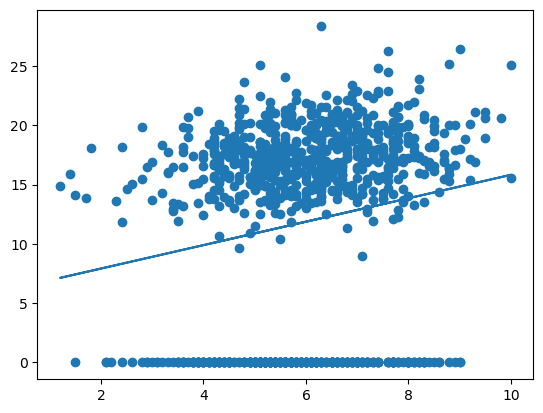

In [8]:
import matplotlib.pyplot as plt
import numpy as np

plt.scatter(df['coding_skills'], df['salary_package_lpa'])
m,c=np.polyfit(df['coding_skills'], df['salary_package_lpa'], 1)
plt.plot(df['coding_skills'],m*df['coding_skills']+c)

In [9]:
X=df['coding_skills']
y=df['salary_package_lpa']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
print("-----X_train-----")
print(X_train)
print("-----X_test-----")
print(X_test)
print("-----y_train-----")
print(y_train)
print("-----y_test-----")
print(y_test)


-----X_train-----
29     6.3
535    4.5
695    5.3
557    4.3
836    4.6
      ... 
106    7.8
270    4.2
860    5.7
435    8.2
102    6.9
Name: coding_skills, Length: 800, dtype: float64
-----X_test-----
521    6.3
737    5.7
740    6.7
660    5.9
411    3.9
      ... 
408    7.4
332    6.9
208    6.3
613    5.6
78     7.7
Name: coding_skills, Length: 200, dtype: float64
-----y_train-----
29     20.47
535    13.69
695     0.00
557     0.00
836    18.09
       ...  
106    21.62
270    16.65
860     0.00
435    17.28
102     0.00
Name: salary_package_lpa, Length: 800, dtype: float64
-----y_test-----
521    14.03
737     0.00
740     0.00
660    20.42
411     0.00
       ...  
408     0.00
332    14.41
208     0.00
613    16.41
78     14.19
Name: salary_package_lpa, Length: 200, dtype: float64


In [11]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()

model.fit(X_train.values.reshape(-1,1),y_train)
model.predict([[30]])

array([35.33543953])

In [12]:
x_pred=model.predict(X_test.values.reshape(-1,1))
x_pred

array([12.41947702, 11.83932607, 12.80624432, 12.03270972, 10.09887322,
       11.35586694, 12.90293614, 13.28970344, 13.09631979, 11.83932607,
       11.74263424,  8.84187949, 13.19301162, 14.93346446,  9.13195497,
       13.19301162, 11.35586694, 10.87240782, 10.67902417, 11.74263424,
       11.74263424, 11.25917512, 13.57977892, 11.35586694, 14.15992986,
       10.87240782, 11.16248329, 12.90293614, 15.99707454,  9.80879774,
       13.67647074, 12.22609337, 13.77316257, 13.96654622, 11.35586694,
       15.03015629, 11.54925059, 10.00218139, 11.83932607, 13.09631979,
       13.09631979, 11.35586694, 11.83932607, 11.45255877, 12.12940154,
       11.45255877, 14.25662169, 12.61286067, 11.74263424, 11.64594242,
       14.83677264, 12.90293614, 10.58233234, 13.57977892, 12.32278519,
        9.71210592, 12.80624432, 10.48564052, 11.45255877, 12.90293614,
       11.35586694, 11.54925059, 12.03270972, 13.48308709, 14.93346446,
       14.35331351, 11.25917512, 11.83932607,  9.51872227, 11.25

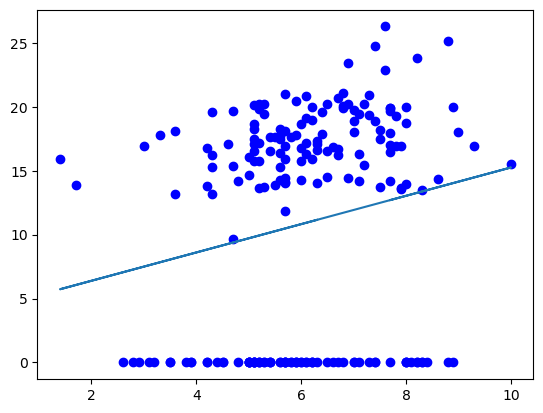

In [13]:
plt.scatter(X_test, y_test, color='blue')
m,c=np.polyfit(X_test, y_test, 1)
plt.plot(X_test,m*X_test+c)

In [14]:
import joblib
print("Saving model for production...")
joblib.dump(model, 'salary_prediction_model.pkl')
joblib.dump(x_pred, 'x_pred.pkl')
joblib.dump(X_test, 'X_test.pkl')
print("✓ Model saved successfully!")
print(f"Model Accuracy (R² Score): {model.score(X_test.values.reshape(-1,1), y_test):.4f}")

Saving model for production...
✓ Model saved successfully!
Model Accuracy (R² Score): 0.0128
